## Assignment

Concrete is the most important material in civil engineering. The concrete compressive strength is a
__highly nonlinear__ function of age and ingredients. These ingredients include cement, blast furnace slag, fly ash, water,
superplasticizer, coarse aggregate, and fine aggregate.

Build a multiple linear regression model to predict concrete compressive strength using mixture composition and curing age.
Use the training data to develop your model. You may consider variable selection, transformations, polynomial terms, and interactions.

Submit:

- Your final regression formula, e.g., "Strength = 12.8 + 0.083*Cement + ...", as a text entry
- A brief explanation of how you selected the final model, as a text entry
- Predicted strengths for the 30 test observations. Submit a .csv file containing two columns: ID, PredictedStrength

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.compat import lzip

In [37]:
df_train = pd.read_csv('concrete_training.csv')
df_test = pd.read_csv('concrete_test.csv')

In [38]:
train_mean = np.mean(df_train)
print(train_mean)


269.2507711442786


In [39]:
df_train

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
0,329.9,170.0,0.0,193.8,8.0,802.1,812.0,29.0,56.61
1,526.1,0.0,0.2,186.8,0.0,1122.1,620.7,14.1,48.40
2,391.9,96.6,0.3,157.8,12.0,873.4,925.2,27.8,50.70
3,213.1,0.0,122.1,180.1,5.7,1051.7,784.6,57.3,34.20
4,257.0,100.5,78.8,203.0,9.1,846.9,760.6,28.1,32.40
...,...,...,...,...,...,...,...,...,...
665,369.5,186.0,0.3,190.4,6.7,819.2,742.4,27.4,65.91
666,268.2,111.8,86.2,181.1,10.1,897.4,734.4,27.2,39.42
667,135.8,202.3,0.0,186.0,0.0,1091.3,769.1,6.9,7.51
668,383.8,0.0,0.2,185.0,0.0,976.9,760.4,7.1,23.22


## EDA

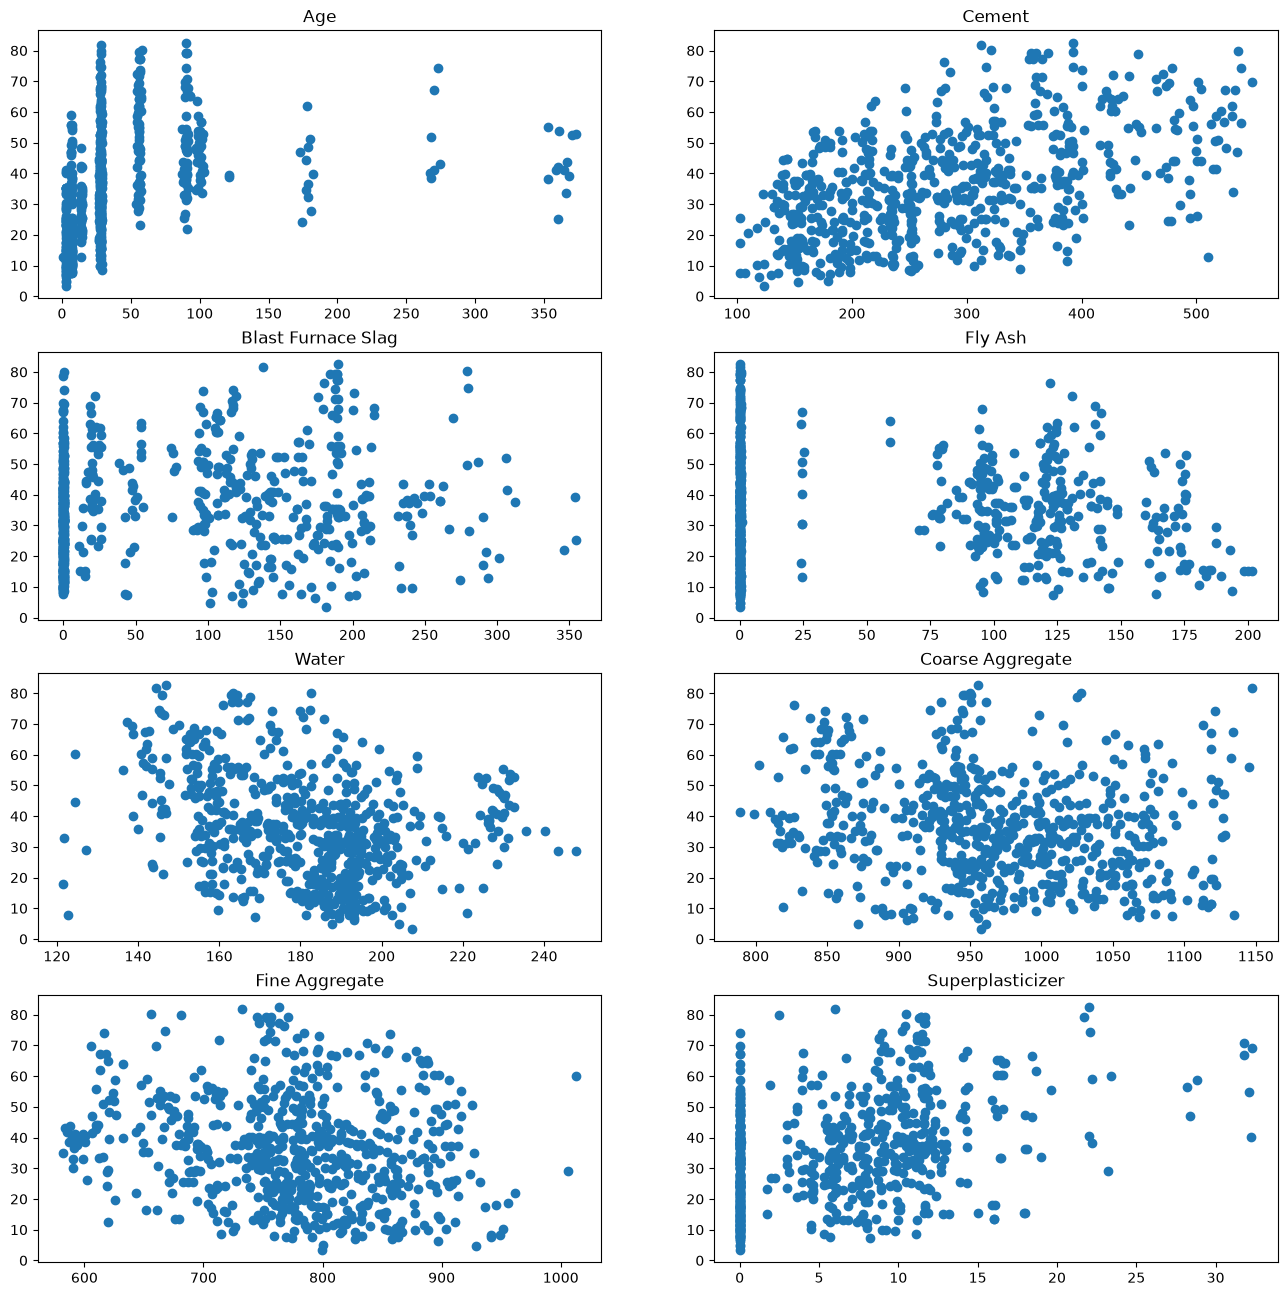

In [40]:
#EDA 
fig = plt.figure(figsize=(16, 16))

age = fig.add_subplot(4,2, 1)
plt.scatter(df_train.Age, df_train.Strength)
age.set_title("Age")

cem = fig.add_subplot(4,2, 2)
plt.scatter(df_train.Cement, df_train.Strength)
cem.set_title("Cement")

slag = fig.add_subplot(4,2, 3)
plt.scatter(df_train.BlastFurnaceSlag, df_train.Strength)
slag.set_title("Blast Furnace Slag")

fly = fig.add_subplot(4,2, 4)
plt.scatter(df_train.FlyAsh, df_train.Strength)
fly.set_title("Fly Ash")

water = fig.add_subplot(4,2, 5)
plt.scatter(df_train.Water, df_train.Strength)
water.set_title("Water")

ca = fig.add_subplot(4,2, 6)
plt.scatter(df_train.CoarseAggregate, df_train.Strength)
ca.set_title("Coarse Aggregate")

fa = fig.add_subplot(4,2, 7)
plt.scatter(df_train.FineAggregate, df_train.Strength)
fa.set_title("Fine Aggregate")

sup = fig.add_subplot(4,2, 8)
plt.scatter(df_train.Superplasticizer, df_train.Strength)
sup.set_title("Superplasticizer")

plt.show()

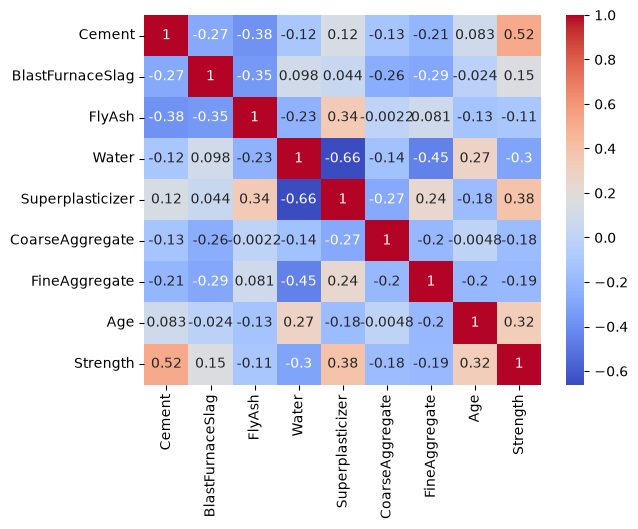

In [41]:
matrix = df_train.corr()
sns.heatmap(matrix, annot=True, cmap="coolwarm")
plt.show()

## Model selection (backwards selection)

In [42]:
#Beginning regressin testing looking for p values to remove (backwards sleection)
model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer + CoarseAggregate + FineAggregate + Age', data=df_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     139.5
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          1.66e-136
Time:                        19:04:40   Log-Likelihood:                -2517.0
No. Observations:                 670   AIC:                             5052.
Df Residuals:                     661   BIC:                             5092.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -7.3851     29.794  

In [43]:
# Removed the Coarse and Fine Aggregate, low p values
model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer + Age', data=df_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     185.9
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          1.90e-138
Time:                        19:04:40   Log-Likelihood:                -2517.7
No. Observations:                 670   AIC:                             5049.
Df Residuals:                     663   BIC:                             5081.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           26.3594      5.257  

## Checking assumptions

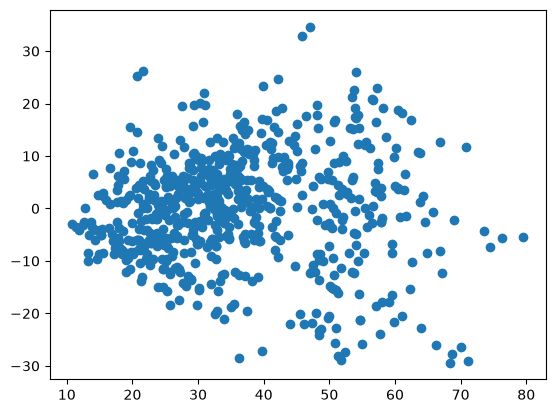

        VIF          variable
0  1.000000         Intercept
1  1.873716            Cement
2  1.791067  BlastFurnaceSlag
3  2.283265            FlyAsh
4  1.942395             Water
5  2.392805  Superplasticizer
6  1.101238               Age
[('LMS', np.float64(87.35284743679757)), ('p', np.float64(1.073778060943166e-16)), ('f', np.float64(16.566612570408275)), ('f p', np.float64(7.583144290374539e-18))]


In [44]:
#checking assumptions with resid plot
plt.scatter(model.fittedvalues, model.resid)
plt.show()

X = model.model.exog
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif['variable'] = model.model.exog_names
print(vif)

names = ['LMS', 'p', 'f', 'f p']
LMS = sms.het_breuschpagan(model.resid, model.model.exog)

print(lzip(names, LMS))
#Heteroscedacity definitely violated

In [45]:
# Weights: model the residual spread from the OLS fit, then weight by 1/variance
ols_model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer + Age', data=df_train).fit()

# Regress |residuals| on fitted values to estimate the std dev of each observation
resid_model = sm.OLS(np.abs(ols_model.resid), sm.add_constant(ols_model.fittedvalues)).fit()
weights = 1 / resid_model.fittedvalues**2

model = smf.wls('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer + Age', data=df_train, weights=weights).fit()
print(model.summary())

                            WLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.668
Model:                            WLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     222.2
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          4.97e-155
Time:                        19:04:40   Log-Likelihood:                -2460.3
No. Observations:                 670   AIC:                             4935.
Df Residuals:                     663   BIC:                             4966.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           14.0735      4.516  

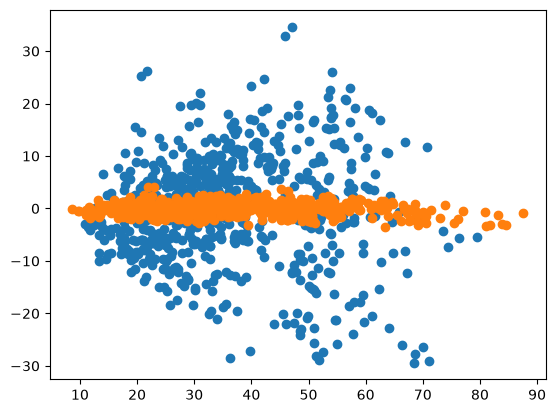

In [46]:
#Use the weighted resids for the scatterplot instead of normal to check heteroscedacity fixed
weight_resid = model.resid * np.sqrt(weights)
plt.scatter(ols_model.fittedvalues, ols_model.resid) #Blue, unweighted
plt.scatter(model.fittedvalues, weight_resid) #Orange, weighted
plt.show()

## Log transform on Age

In [52]:
# Log transform on Age: strength rises fast early then levels off, so log(Age) fits better than a straight line

log_model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer + np.log(Age)', data=df_train).fit(cov_type='HC3')
print(log_model.summary())

# Heteroscedasticity is reduced by the log transform but still present, which is why HC3 is used
LMS = sms.het_breuschpagan(log_model.resid, log_model.model.exog)
print(lzip(['LMS', 'p', 'f', 'f p'], LMS))

                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     488.9
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          1.36e-239
Time:                        19:08:32   Log-Likelihood:                -2282.5
No. Observations:                 670   AIC:                             4579.
Df Residuals:                     663   BIC:                             4610.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            9.8999      4.762  

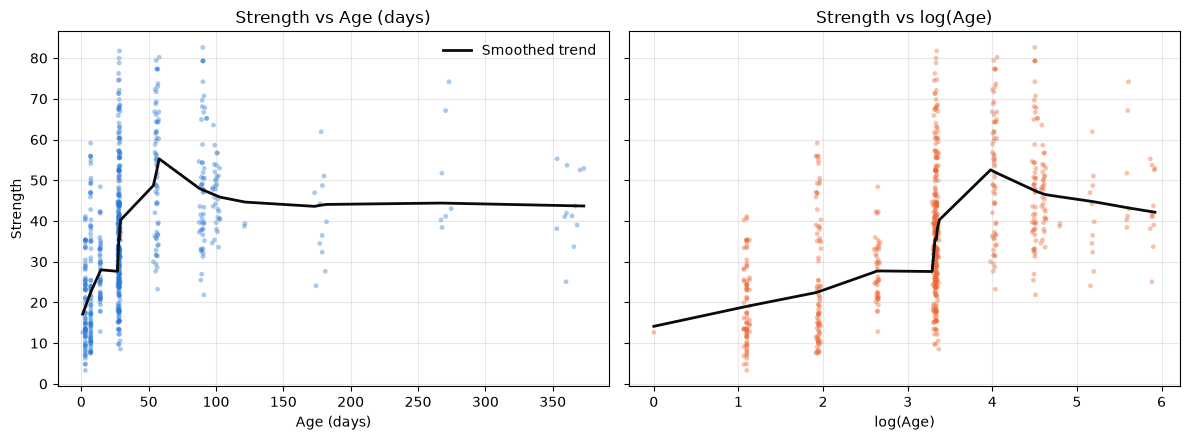

In [48]:
# Fit both models side by side so the plots below can compare them
linear_model = smf.ols('Strength ~ Cement + BlastFurnaceSlag + FlyAsh + Water + Superplasticizer + Age', data=df_train).fit()

LINEAR_COLOR = '#2a78d6'  # blue = linear Age
LOG_COLOR = '#eb6834'     # orange = log(Age)
lowess = sm.nonparametric.lowess

# Strength vs Age and vs log(Age), with a smoothed trend line to show the shape
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, x, label, color in [(axes[0], df_train.Age, 'Age (days)', LINEAR_COLOR),
                            (axes[1], np.log(df_train.Age), 'log(Age)', LOG_COLOR)]:
    ax.scatter(x, df_train.Strength, s=12, alpha=0.4, color=color, edgecolors='none')
    trend = lowess(df_train.Strength, x, frac=0.3)
    ax.plot(trend[:, 0], trend[:, 1], color='#0b0b0b', linewidth=2, label='Smoothed trend')
    ax.set_xlabel(label)
    ax.set_title(f'Strength vs {label}')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Strength')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

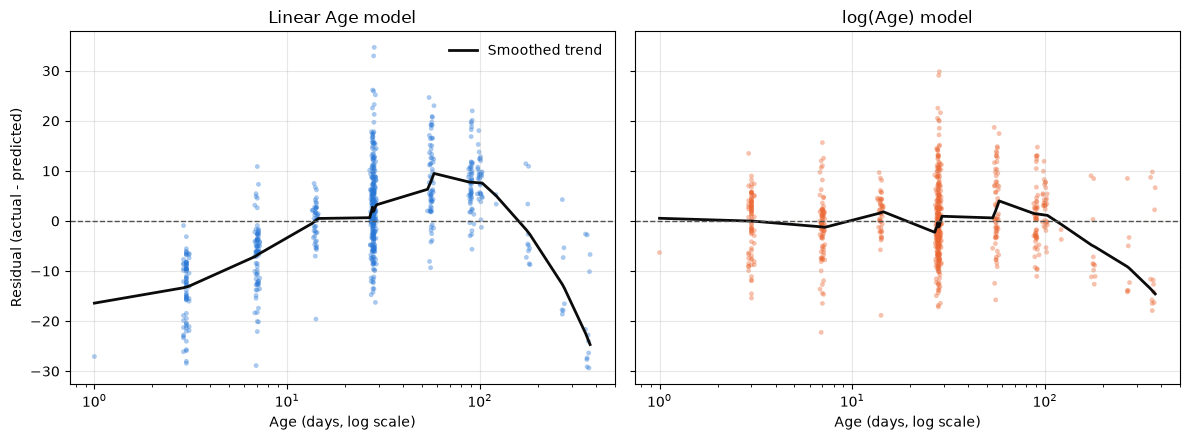

In [49]:
# Residuals vs Age: the linear-Age model leaves a curved pattern, the log(Age) model doesn't
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, m, name, color in [(axes[0], linear_model, 'Linear Age model', LINEAR_COLOR),
                           (axes[1], log_model, 'log(Age) model', LOG_COLOR)]:
    ax.scatter(df_train.Age, m.resid, s=12, alpha=0.4, color=color, edgecolors='none')
    trend = lowess(m.resid, df_train.Age, frac=0.3)
    ax.plot(trend[:, 0], trend[:, 1], color='#0b0b0b', linewidth=2, label='Smoothed trend')
    ax.axhline(0, color='#52514e', linewidth=1, linestyle='--')
    ax.set_xscale('log')  # spreads out the early ages so the pattern is visible
    ax.set_xlabel('Age (days, log scale)')
    ax.set_title(name)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

## Final model

Ordinary least squares on the training data (670 rows), adjusted R² = 0.814. `ln` is the natural log (`np.log`).

```
Strength = 9.8999 + 0.1107*Cement + 0.0881*BlastFurnaceSlag + 0.0611*FlyAsh - 0.2362*Water + 0.0558*Superplasticizer + 8.7006*ln(Age)
```

The Breusch–Pagan test still showed heteroscedasticity after the log(Age) transform (p ≈ 3e-7), so p-values use HC3 robust standard errors. HC3 doesn't change the coefficients or predictions above. WLS was also tried but didn't improve prediction error, so OLS was kept.

## Predictions

In [50]:
#predicting test set strengths with the log(Age) model
test_pred = log_model.predict(df_test)

predictions = pd.DataFrame({'ID': df_test['ID'], 'PredictedStrength': test_pred})
print(predictions)
print(predictions['PredictedStrength'].describe())

predictions.to_csv('concrete_predictions.csv', index=False)


    ID  PredictedStrength
0    1          33.257702
1    2          48.168749
2    3          37.057977
3    4          44.356829
4    5          42.503025
5    6          10.903527
6    7          14.530968
7    8          44.128829
8    9          41.759349
9   10          34.252125
10  11           9.512455
11  12          28.245895
12  13          67.311981
13  14          39.510694
14  15          37.755353
15  16          34.037948
16  17          60.884181
17  18          27.062409
18  19          18.080897
19  20          57.781677
20  21          34.509644
21  22          23.472062
22  23          24.922689
23  24          25.908218
24  25          42.437574
25  26          -1.781635
26  27          45.781727
27  28          53.995871
28  29          32.238315
29  30          65.688646
count    30.000000
mean     35.942523
std      16.489878
min      -1.781635
25%      26.196765
50%      35.783811
75%      44.299829
max      67.311981
Name: PredictedStrength, dtype: float64


In [51]:
# printing sorted valus to see if there were any other very low age values in the test set
print(df_test.sort_values(by='Age')[["ID", 'Age']])

    ID    Age
10  11    3.0
25  26    3.0
26  27    6.9
5    6    6.9
6    7    7.0
18  19    7.1
2    3   14.1
22  23   14.2
23  24   27.2
14  15   27.8
13  14   27.9
8    9   28.0
0    1   28.0
24  25   28.1
17  18   28.3
20  21   28.4
28  29   28.4
15  16   28.5
11  12   28.5
21  22   28.6
16  17   29.0
29  30   54.7
3    4   55.5
12  13   91.5
9   10   92.5
27  28   99.8
1    2  180.0
4    5  271.4
7    8  275.6
19  20  364.5
